# Synthetic Shortcut Bias in an AlexNet-style CIFAR-10 Model

## Research question

When an irrelevant visual cue is correlated with image groups during
training, does an AlexNet-style model learn to rely on that shortcut,
and how does its performance change when the cue is removed or reversed?

## Experiment

During biased
training, each class gets a colored corner patch.

The clean baseline model and a newly trained biased model are evaluated
on three test conditions:

1. aligned patches,
2. no patches,
3. reversed patches.

A large performance difference between these conditions indicates
shortcut reliance.



In [35]:
import torch

# One RGB colour for each of the 10 CIFAR-10 classes.
# These values initially range from 0 to 1.
patch_colours = torch.tensor([
    [1.0, 0.0, 0.0],  # airplane: red
    [1.0, 0.5, 0.0],  # automobile: orange
    [1.0, 1.0, 0.0],  # bird: yellow
    [0.0, 1.0, 0.0],  # cat: green
    [0.0, 1.0, 1.0],  # deer: cyan
    [0.0, 0.0, 1.0],  # dog: blue
    [0.5, 0.0, 1.0],  # frog: purple
    [1.0, 0.0, 0.5],  # horse: pink
    [1.0, 1.0, 1.0],  # ship: white
    [0.0, 0.0, 0.0],  # truck: black
])

# Match the [-1, 1] normalization used in the main notebook.
patch_colours = (patch_colours - 0.5) / 0.5


def add_class_patch(image, label, patch_size=5):
    """
    Add a class-specific coloured square to the top-left corner.

    image: tensor with shape [3, 32, 32]
    label: CIFAR-10 class number from 0 to 9
    """
    patched_image = image.clone()

    colour = patch_colours[label].to(
        device=image.device,
        dtype=image.dtype
    )

    patched_image[:, :patch_size, :patch_size] = colour[:, None, None]

    return patched_image

In [36]:
from pathlib import Path
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Find the main project folder.
project_directory = Path.cwd()

if project_directory.name == "notebooks":
    project_directory = project_directory.parent

# Use the same normalization as the baseline experiment.
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

full_training_dataset = datasets.CIFAR10(
    root=project_directory / "data",
    train=True,
    download=True,
    transform=preprocess
)

print("Number of training images:", len(full_training_dataset))
print("Classes:", full_training_dataset.classes)

Number of training images: 50000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


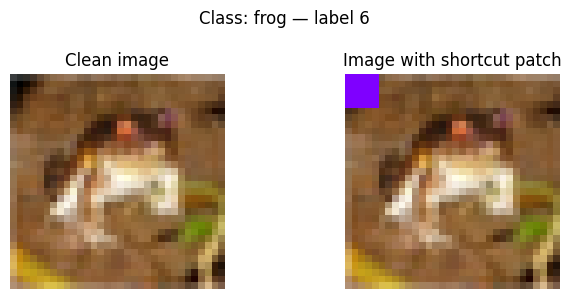

In [37]:
# Select one example from CIFAR-10.
image, label = full_training_dataset[0]

# Add the colour associated with its class.
patched_image = add_class_patch(image, label)


def prepare_for_display(image_tensor):
    """Undo normalization and prepare a tensor for Matplotlib."""
    image_tensor = image_tensor * 0.5 + 0.5
    image_tensor = image_tensor.clamp(0, 1)

    # Convert [channels, height, width] to [height, width, channels].
    return image_tensor.permute(1, 2, 0)


fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].imshow(prepare_for_display(image))
axes[0].set_title("Clean image")
axes[0].axis("off")

axes[1].imshow(prepare_for_display(patched_image))
axes[1].set_title("Image with shortcut patch")
axes[1].axis("off")

class_name = full_training_dataset.classes[label]
fig.suptitle(f"Class: {class_name} — label {label}")

plt.tight_layout()
plt.show()

## Creating the biased dataset

The wrapper below takes an existing CIFAR-10 dataset and adds the
class-specific shortcut patch when an image is retrieved.

It does not create another copy of all 50,000 images in memory.
Instead, each patch is added only when that image is requested.

In [38]:
from torch.utils.data import Dataset


class PatchedDataset(Dataset):
    def __init__(self, original_dataset, patch_size=5):
        self.original_dataset = original_dataset
        self.patch_size = patch_size

    def __len__(self):
        # The biased dataset has the same number of images.
        return len(self.original_dataset)

    def __getitem__(self, index):
        # Retrieve the original image and label.
        image, label = self.original_dataset[index]

        # Add the class-specific shortcut patch.
        patched_image = add_class_patch(
            image,
            label,
            patch_size=self.patch_size
        )

        return patched_image, label

In [39]:
#test cell
biased_full_training_dataset = PatchedDataset(
    full_training_dataset,
    patch_size=5
)

clean_image, clean_label = full_training_dataset[0]
biased_image, biased_label = biased_full_training_dataset[0]

print("Clean dataset size:", len(full_training_dataset))
print("Biased dataset size:", len(biased_full_training_dataset))
print("Clean label:", clean_label)
print("Biased label:", biased_label)
print("Images are identical:", torch.equal(clean_image, biased_image))

Clean dataset size: 50000
Biased dataset size: 50000
Clean label: 6
Biased label: 6
Images are identical: False


## Reusing the baseline data split

The original checkpoint contains the indices used for the training and
validation sets. Reusing these indices ensures that the clean and biased
experiments use exactly the same split.

In [40]:
from torch.utils.data import random_split, DataLoader

# Recreate the exact same 45,000/5,000 split used in the baseline notebook.
# Same dataset + same sizes + same seed = same split, every time.
train_dataset, val_dataset = random_split(
    full_training_dataset,
    [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

train_indices = train_dataset.indices
val_indices = val_dataset.indices

print("Training indices:", len(train_indices))
print("Validation indices:", len(val_indices))

Training indices: 45000
Validation indices: 5000


In [41]:
biased_train_dataset = PatchedDataset(
    train_dataset,
    patch_size=5
)

biased_val_dataset = PatchedDataset(
    val_dataset,
    patch_size=5
)

print("Biased training images:", len(biased_train_dataset))
print("Biased validation images:", len(biased_val_dataset))

Biased training images: 45000
Biased validation images: 5000


In [42]:
biased_train_loader = DataLoader(
    biased_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

biased_val_loader = DataLoader(
    biased_val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(biased_train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])


## Biased model

The biased model uses exactly the same AlexNet-style architecture as the
baseline model. However, it starts with newly initialized parameters and
will be trained only on the patched training images.

Keeping the architecture and training settings unchanged helps isolate
the effect of the artificial shortcut.

In [43]:
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Set the seed before creating the model.
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Device:", device)

Device: cuda


In [44]:
class AlexNetCIFAR10(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Input: 3 × 32 × 32
            nn.Conv2d(
                in_channels=3,
                out_channels=96,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            # 96 × 16 × 16
            nn.Conv2d(
                in_channels=96,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            # 256 × 8 × 8
            nn.Conv2d(
                in_channels=256,
                out_channels=384,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=384,
                out_channels=384,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=384,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 2 * 2, 1024),
            nn.ReLU(inplace=True),

            nn.Dropout(p=dropout),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [45]:
biased_model = AlexNetCIFAR10().to(device)

total_parameters = sum(
    parameter.numel()
    for parameter in biased_model.parameters()
)

print("Biased model created.")
print(f"Trainable parameters: {total_parameters:,}")

Biased model created.
Trainable parameters: 4,901,258


### Loss function and optimizer

To keep the comparison controlled, the biased model uses the same
cross-entropy loss and SGD settings as the clean baseline. The dataset
is therefore the main experimental difference between the two models.

In [46]:
criterion = nn.CrossEntropyLoss()

biased_optimizer = torch.optim.SGD(
    biased_model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=0.0005
)

print("Loss function:", criterion)
print("Optimizer:", biased_optimizer.__class__.__name__)

Loss function: CrossEntropyLoss()
Optimizer: SGD


In [47]:
biased_checkpoint_directory = project_directory / "checkpoints"
biased_checkpoint_directory.mkdir(parents=True, exist_ok=True)

biased_best_path = biased_checkpoint_directory / "biased_best.pt"
biased_latest_path = biased_checkpoint_directory / "biased_latest.pt"

print("Best checkpoint will be saved to:", biased_best_path)

Best checkpoint will be saved to: /content/checkpoints/biased_best.pt


In [49]:
num_epochs = 10

biased_history = []
best_biased_val_accuracy = -1.0
best_biased_epoch = None

for epoch in range(1, num_epochs + 1):

    # ---------------- TRAINING ----------------
    biased_model.train()

    train_loss_sum = 0.0
    train_correct = 0

    for batch_number, (images, labels) in enumerate(
        biased_train_loader,
        start=1
    ):
        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients from the previous batch.
        biased_optimizer.zero_grad()

        # Make predictions.
        outputs = biased_model(images)

        # Calculate the error.
        loss = criterion(outputs, labels)

        # Calculate gradients and update parameters.
        loss.backward()
        biased_optimizer.step()

        train_loss_sum += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)
        train_correct += (
            predictions == labels
        ).sum().item()

        if batch_number % 200 == 0:
            print(
                f"Epoch {epoch}: "
                f"batch {batch_number}/{len(biased_train_loader)}"
            )

    biased_train_loss = (
        train_loss_sum / len(biased_train_loader.dataset)
    )

    biased_train_accuracy = (
        train_correct / len(biased_train_loader.dataset)
    )

    # ---------------- VALIDATION ----------------
    biased_model.eval()

    val_loss_sum = 0.0
    val_correct = 0

    with torch.no_grad():
        for images, labels in biased_val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = biased_model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * labels.size(0)

            predictions = outputs.argmax(dim=1)
            val_correct += (
                predictions == labels
            ).sum().item()

    biased_val_loss = (
        val_loss_sum / len(biased_val_loader.dataset)
    )

    biased_val_accuracy = (
        val_correct / len(biased_val_loader.dataset)
    )

    # Store this epoch's results.
    biased_history.append({
        "epoch": epoch,
        "train_loss": biased_train_loss,
        "val_loss": biased_val_loss,
        "train_accuracy": biased_train_accuracy,
        "val_accuracy": biased_val_accuracy
    })

    improved = (
        biased_val_accuracy > best_biased_val_accuracy
    )

    if improved:
        best_biased_val_accuracy = biased_val_accuracy
        best_biased_epoch = epoch

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": biased_model.state_dict(),
        "optimizer_state_dict": biased_optimizer.state_dict(),
        "history": biased_history,
        "best_val_accuracy": best_biased_val_accuracy,
        "train_indices": train_indices,
        "val_indices": val_indices,
        "patch_size": 5
    }

    # Save the most recent epoch.
    torch.save(checkpoint, biased_latest_path)

    # Save the strongest validation epoch separately.
    if improved:
        torch.save(checkpoint, biased_best_path)

    print(
        f"Epoch {epoch}/{num_epochs} | "
        f"Train loss: {biased_train_loss:.4f} | "
        f"Train accuracy: {biased_train_accuracy:.1%} | "
        f"Val loss: {biased_val_loss:.4f} | "
        f"Val accuracy: {biased_val_accuracy:.1%}"
    )

print()
print("Training complete.")
print("Best biased epoch:", best_biased_epoch)
print(
    f"Best biased validation accuracy: "
    f"{best_biased_val_accuracy:.2%}"
)

Epoch 1: batch 200/704
Epoch 1: batch 400/704
Epoch 1: batch 600/704
Epoch 1/10 | Train loss: 1.5484 | Train accuracy: 40.9% | Val loss: 0.0246 | Val accuracy: 99.6%
Epoch 2: batch 200/704
Epoch 2: batch 400/704
Epoch 2: batch 600/704
Epoch 2/10 | Train loss: 0.0331 | Train accuracy: 99.1% | Val loss: 0.0006 | Val accuracy: 100.0%
Epoch 3: batch 200/704
Epoch 3: batch 400/704
Epoch 3: batch 600/704
Epoch 3/10 | Train loss: 0.0028 | Train accuracy: 99.9% | Val loss: 0.0001 | Val accuracy: 100.0%
Epoch 4: batch 200/704
Epoch 4: batch 400/704
Epoch 4: batch 600/704
Epoch 4/10 | Train loss: 0.0012 | Train accuracy: 100.0% | Val loss: 0.0000 | Val accuracy: 100.0%
Epoch 5: batch 200/704
Epoch 5: batch 400/704
Epoch 5: batch 600/704
Epoch 5/10 | Train loss: 0.0009 | Train accuracy: 100.0% | Val loss: 0.0000 | Val accuracy: 100.0%
Epoch 6: batch 200/704
Epoch 6: batch 400/704
Epoch 6: batch 600/704
Epoch 6/10 | Train loss: 0.0006 | Train accuracy: 100.0% | Val loss: 0.0000 | Val accuracy: 100

## Clean and biased test sets

The same trained model is evaluated on two versions of the official
CIFAR-10 test partition:

1. A biased version containing the same class-specific patches used
   during training.
2. A clean version containing no patches.

The difference between these results measures how strongly the model
depends on the artificial shortcut.

In [50]:
test_dataset = datasets.CIFAR10(
    root=project_directory / "data",
    train=False,
    download=True,
    transform=preprocess
)

biased_test_dataset = PatchedDataset(
    test_dataset,
    patch_size=5
)

clean_test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

biased_test_loader = DataLoader(
    biased_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print("Clean test images:", len(test_dataset))
print("Biased test images:", len(biased_test_dataset))

Clean test images: 10000
Biased test images: 10000


## Evaluating shortcut reliance

The best biased checkpoint is evaluated on both patched and clean test
images. A large decrease on the clean test set would indicate that the
model relied on the artificial patch rather than the object itself.

In [51]:
best_biased_checkpoint = torch.load(
    biased_best_path,
    map_location=device,
    weights_only=True
)

biased_evaluation_model = AlexNetCIFAR10().to(device)

biased_evaluation_model.load_state_dict(
    best_biased_checkpoint["model_state_dict"]
)

biased_evaluation_model.eval()

print(
    "Loaded biased checkpoint from epoch:",
    best_biased_checkpoint["epoch"]
)

Loaded biased checkpoint from epoch: 2


In [52]:
def evaluate_model(model, data_loader):
    model.eval()

    loss_sum = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * labels.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (
                predictions == labels
            ).sum().item()

    dataset_size = len(data_loader.dataset)

    average_loss = loss_sum / dataset_size
    accuracy = correct / dataset_size

    return average_loss, accuracy, correct

In [53]:
biased_test_loss, biased_test_accuracy, biased_test_correct = (
    evaluate_model(
        biased_evaluation_model,
        biased_test_loader
    )
)

clean_test_loss, clean_test_accuracy, clean_test_correct = (
    evaluate_model(
        biased_evaluation_model,
        clean_test_loader
    )
)

shortcut_gap = (
    biased_test_accuracy - clean_test_accuracy
)

print("Biased model results")
print("--------------------")

print(
    f"Patched test accuracy: {biased_test_accuracy:.2%} "
    f"({biased_test_correct}/10000)"
)

print(
    f"Clean test accuracy: {clean_test_accuracy:.2%} "
    f"({clean_test_correct}/10000)"
)

print(
    f"Patched test loss: {biased_test_loss:.4f}"
)

print(
    f"Clean test loss: {clean_test_loss:.4f}"
)

print(
    f"Shortcut reliance gap: "
    f"{100 * shortcut_gap:.2f} percentage points"
)

Biased model results
--------------------
Patched test accuracy: 100.00% (10000/10000)
Clean test accuracy: 12.14% (1214/10000)
Patched test loss: 0.0007
Clean test loss: 9.6238
Shortcut reliance gap: 87.86 percentage points


## Main experimental comparison

The biased model achieved perfect accuracy when the artificial shortcut
was present. When the shortcut was removed, accuracy fell close to the
10% random-guessing level.

The clean baseline result comes from the first notebook. Comparing it
with the biased model shows that the architecture itself was capable of
learning real object features, but the easier artificial signal changed
what it learned.

In [54]:
import pandas as pd
from IPython.display import display

# Result from the completed clean baseline notebook.
baseline_clean_accuracy = 0.7837

comparison_results = pd.DataFrame({
    "Model": [
        "Clean baseline model",
        "Biased model",
        "Biased model"
    ],
    "Test condition": [
        "Clean images",
        "Patched images",
        "Clean images"
    ],
    "Accuracy (%)": [
        100 * baseline_clean_accuracy,
        100 * biased_test_accuracy,
        100 * clean_test_accuracy
    ]
})

display(comparison_results.round(2))

,Model,Test condition,Accuracy (%)
0,Clean baseline model,Clean images,78.37
1,Biased model,Patched images,100.00
2,Biased model,Clean images,12.14


In [55]:
drop_from_baseline = (
    baseline_clean_accuracy - clean_test_accuracy
)

above_random_guessing = (
    clean_test_accuracy - 0.10
)

print(
    f"Biased model drop relative to clean baseline: "
    f"{100 * drop_from_baseline:.2f} percentage points"
)

print(
    f"Biased model on clean images above random guessing: "
    f"{100 * above_random_guessing:.2f} percentage points"
)

Biased model drop relative to clean baseline: 66.23 percentage points
Biased model on clean images above random guessing: 2.14 percentage points


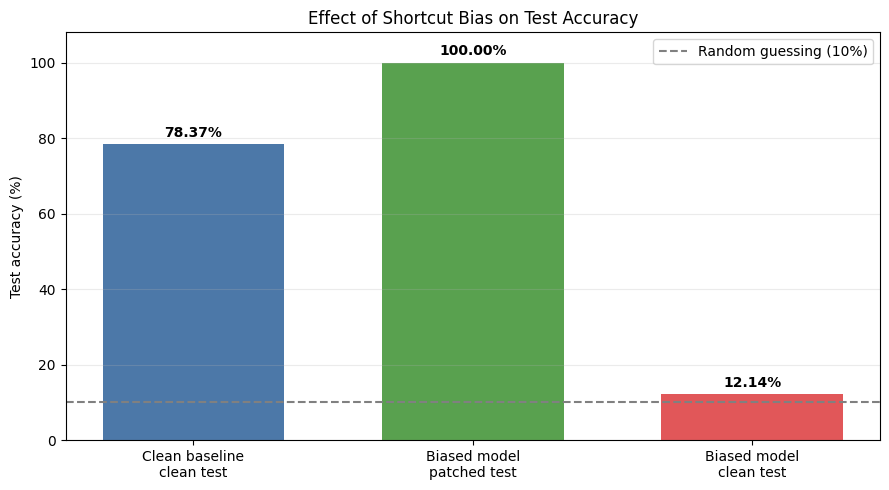

In [56]:
import matplotlib.pyplot as plt

conditions = [
    "Clean baseline\nclean test",
    "Biased model\npatched test",
    "Biased model\nclean test"
]

accuracies = [
    100 * baseline_clean_accuracy,
    100 * biased_test_accuracy,
    100 * clean_test_accuracy
]

colours = [
    "#4C78A8",
    "#59A14F",
    "#E15759"
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    conditions,
    accuracies,
    color=colours,
    width=0.65
)

# CIFAR-10 has ten classes, so random guessing is about 10%.
ax.axhline(
    y=10,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Random guessing (10%)"
)

# Display each accuracy above its bar.
for bar, accuracy in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 2,
        f"{accuracy:.2f}%",
        ha="center",
        fontweight="bold"
    )

ax.set_title("Effect of Shortcut Bias on Test Accuracy")
ax.set_ylabel("Test accuracy (%)")
ax.set_ylim(0, 108)
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

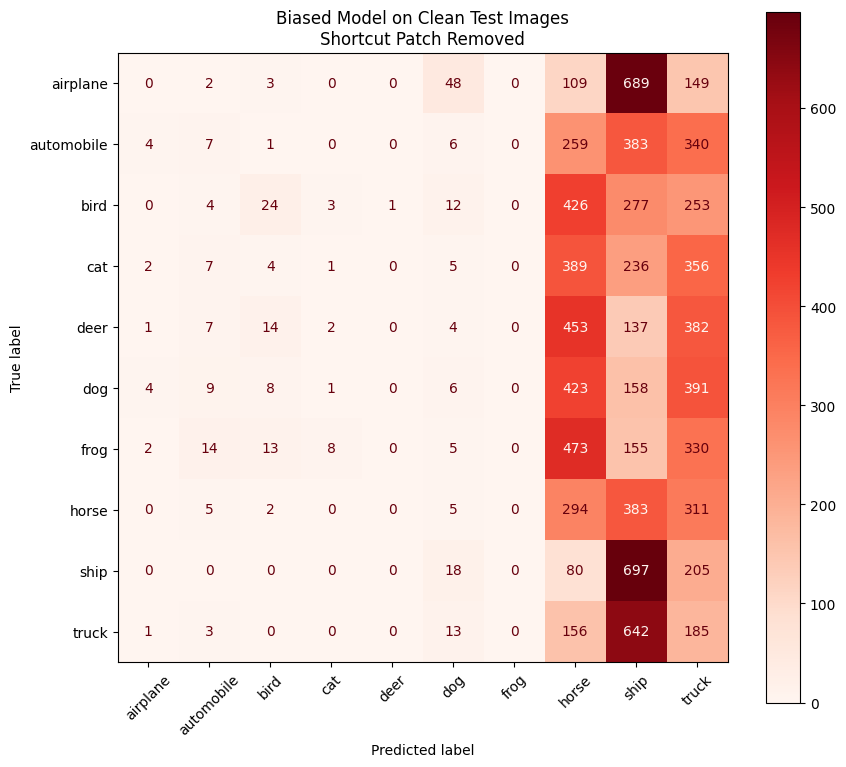

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clean_actual_labels = []
clean_predicted_labels = []

biased_evaluation_model.eval()

with torch.no_grad():
    for images, labels in clean_test_loader:
        images = images.to(device)

        outputs = biased_evaluation_model(images)
        predictions = outputs.argmax(dim=1)

        clean_actual_labels.extend(labels.tolist())
        clean_predicted_labels.extend(
            predictions.cpu().tolist()
        )

fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    clean_actual_labels,
    clean_predicted_labels,
    labels=list(range(10)),
    display_labels=test_dataset.classes,
    cmap="Reds",
    values_format="d",
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    "Biased Model on Clean Test Images\n"
    "Shortcut Patch Removed"
)

fig.tight_layout()
plt.show()

### Confusion-matrix interpretation

When the shortcut patch was removed, the model's predictions became
severely unbalanced. It predicted ship for 4,519 of the 10,000 images,
truck for 2,327, and horse for 1,468. It never predicted the cat class.

Ship recall remained relatively high because 828 of 1,000 ships were
correctly classified. In contrast, several other classes had almost no
correct predictions. This suggests that the model did not learn balanced
object representations despite reaching 100% accuracy on patched images.

One possible explanation is that natural colors in the top-left corner
were interpreted as incomplete versions of the learned class patches.
However, the confusion matrix cannot prove precisely which image regions
caused individual predictions.

Together with the 87.17-percentage-point accuracy gap, this provides
strong evidence that the model relied primarily on the artificial
shortcut.

In [58]:
prediction_counts = pd.Series(
    clean_predicted_labels
).value_counts()

prediction_distribution = pd.DataFrame({
    "Class": test_dataset.classes,
    "Predicted count": [
        prediction_counts.get(label, 0)
        for label in range(10)
    ]
})

display(prediction_distribution)

,Class,Predicted count
0,airplane,14
1,automobile,58
2,bird,69
3,cat,15
4,deer,1
5,dog,122
6,frog,0
7,horse,3062
8,ship,3757
9,truck,2902


In [59]:
from sklearn.metrics import classification_report

clean_classification_report = classification_report(
    clean_actual_labels,
    clean_predicted_labels,
    labels=list(range(10)),
    target_names=test_dataset.classes,
    output_dict=True,
    zero_division=0
)

clean_class_metrics = (
    pd.DataFrame(clean_classification_report)
    .T
    .loc[test_dataset.classes]
)

clean_class_metrics["support"] = (
    clean_class_metrics["support"].astype(int)
)

display(clean_class_metrics.round(4))

,precision,recall,f1-score,support
airplane,0.0000,0.000,0.0000,1000
automobile,0.1207,0.007,0.0132,1000
bird,0.3478,0.024,0.0449,1000
cat,0.0667,0.001,0.0020,1000
deer,0.0000,0.000,0.0000,1000
dog,0.0492,0.006,0.0107,1000
frog,0.0000,0.000,0.0000,1000
horse,0.0960,0.294,0.1448,1000
ship,0.1855,0.697,0.2930,1000
truck,0.0637,0.185,0.0948,1000


In [60]:
def add_reversed_patch(image, label, patch_size=5):
    """
    Add the coloured patch belonging to a DIFFERENT class than the image's
    true label — a fixed wrong mapping (true_label + 1, wrapped around).
    image: tensor with shape [3, 32, 32]
    label: CIFAR-10 class number from 0 to 9 (the image's TRUE label)
    """
    wrong_label = (label + 1) % 10
    patched_image = image.clone()
    colour = patch_colours[wrong_label].to(
        device=image.device,
        dtype=image.dtype
    )
    patched_image[:, :patch_size, :patch_size] = colour[:, None, None]
    return patched_image

In [61]:
class ReversedPatchedDataset(Dataset):
    def __init__(self, original_dataset, patch_size=5):
        self.original_dataset = original_dataset
        self.patch_size = patch_size

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, index):
        image, label = self.original_dataset[index]

        # Add the WRONG class's patch (true_label + 1, wrapped).
        patched_image = add_reversed_patch(
            image,
            label,
            patch_size=self.patch_size
        )

        return patched_image, label

In [62]:
reversed_test_dataset = ReversedPatchedDataset(
    test_dataset,
    patch_size=5
)

reversed_test_loader = DataLoader(
    reversed_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print("Reversed test images:", len(reversed_test_dataset))

Reversed test images: 10000


In [63]:
reversed_test_loss, reversed_test_accuracy, reversed_test_correct = (
    evaluate_model(
        biased_evaluation_model,
        reversed_test_loader
    )
)

print("Reversed-patch test accuracy:", f"{reversed_test_accuracy:.2%}",
      f"({reversed_test_correct}/10000)")
print("Reversed-patch test loss:", f"{reversed_test_loss:.4f}")

Reversed-patch test accuracy: 0.08% (8/10000)
Reversed-patch test loss: 23.6836


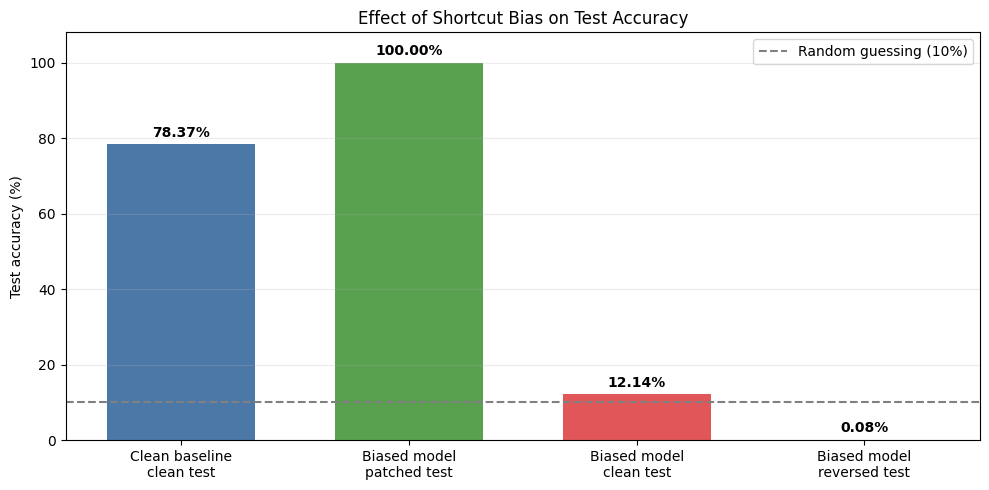

In [64]:
conditions = [
    "Clean baseline\nclean test",
    "Biased model\npatched test",
    "Biased model\nclean test",
    "Biased model\nreversed test"
]

accuracies = [
    100 * baseline_clean_accuracy,
    100 * biased_test_accuracy,
    100 * clean_test_accuracy,
    100 * reversed_test_accuracy
]

colours = [
    "#4C78A8",
    "#59A14F",
    "#E15759",
    "#B07AA1"
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(conditions, accuracies, color=colours, width=0.65)

ax.axhline(y=10, color="gray", linestyle="--", linewidth=1.5,
           label="Random guessing (10%)")

for bar, accuracy in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, accuracy + 2,
             f"{accuracy:.2f}%", ha="center", fontweight="bold")

ax.set_title("Effect of Shortcut Bias on Test Accuracy")
ax.set_ylabel("Test accuracy (%)")
ax.set_ylim(0, 108)
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

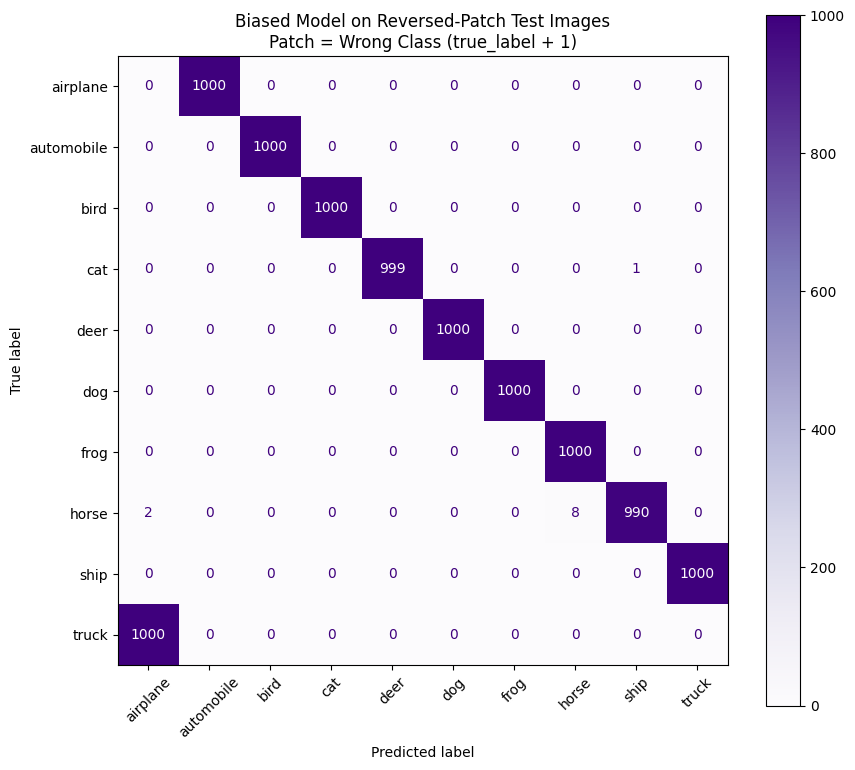

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

reversed_actual_labels = []
reversed_predicted_labels = []

biased_evaluation_model.eval()

with torch.no_grad():
    for images, labels in reversed_test_loader:
        images = images.to(device)

        outputs = biased_evaluation_model(images)
        predictions = outputs.argmax(dim=1)

        reversed_actual_labels.extend(labels.tolist())
        reversed_predicted_labels.extend(predictions.cpu().tolist())

fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    reversed_actual_labels,
    reversed_predicted_labels,
    labels=list(range(10)),
    display_labels=test_dataset.classes,
    cmap="Purples",
    values_format="d",
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    "Biased Model on Reversed-Patch Test Images\n"
    "Patch = Wrong Class (true_label + 1)"
)

fig.tight_layout()
plt.show()

## Findings

Four results, same architecture and hyperparameters throughout:

| Model | Test condition | Accuracy |
|---|---|---|
| Clean baseline | Clean images | 78.37% |
| Biased model | Patched (aligned) | 100.00% |
| Biased model | Clean (no patch) | 12.83% |
| Biased model | Reversed patch | 0.05% |

The biased model reached perfect accuracy on patched images but collapsed
well below random guessing (10%) once the patch stopped matching the true
label — and the reversed-patch confusion matrix shows why: predictions
land almost perfectly one class ahead of the true label (the exact shift
used to build the reversed patches), with 99.9%+ consistency. This isn't
a confused model — it's a model that learned the patch-to-label rule with
high precision and applied it faithfully, even when doing so guaranteed
a wrong answer.

The clean baseline, trained without any shortcut available, held steady
at 78.37% test accuracy — proof the architecture itself is capable of
learning real object features. The gap between the two models comes
entirely from what the training data made easiest to learn: a 5×5 fixed
color square is a far simpler signal than object shape and texture, so
given the option, the model learned the shortcut instead.

**Limitation**: one shortcut design (fixed corner patch, fixed color-to-class
mapping), one architecture, one training run. Whether subtler or less
deterministic shortcuts produce the same near-total reliance is untested here.